# Decision Tree Regression on W3regr Dataset

This notebook demonstrates decision tree regression using the w3regr.csv dataset.

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import plot_tree
import warnings

warnings.filterwarnings("ignore")

In [2]:
# 加载数据
data = pd.read_csv("../datasets/w3regr.csv", header=None, names=["X", "y"])

# 查看数据基本信息
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nDataset info:")
print(data.info())
print("\nBasic statistics:")
print(data.describe())

Dataset shape: (81, 2)

First few rows:
     X           y
0 -5.0  123.867799
1 -4.9   63.138296
2 -4.8    4.163196
3 -4.7   -0.163918
4 -4.6  -33.727488

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       81 non-null     float64
 1   y       81 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB
None

Basic statistics:
               X           y
count  81.000000   81.000000
mean   -1.000000  -31.954204
std     2.352658   45.178432
min    -5.000000 -136.873070
25%    -3.000000  -67.873059
50%    -1.000000  -20.579055
75%     1.000000   -2.436370
max     3.000000  123.867799


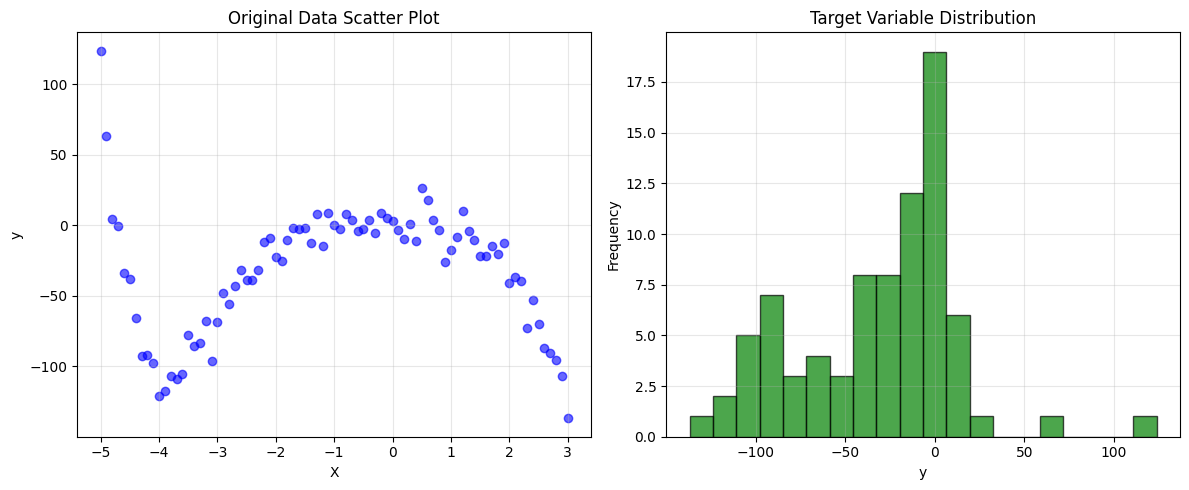

In [3]:
# 数据可视化
plt.figure(figsize=(12, 5))

# 原始数据散点图
plt.subplot(1, 2, 1)
plt.scatter(data["X"], data["y"], alpha=0.6, color="blue")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Original Data Scatter Plot")
plt.grid(True, alpha=0.3)

# 目标变量分布
plt.subplot(1, 2, 2)
plt.hist(data["y"], bins=20, alpha=0.7, color="green", edgecolor="black")
plt.xlabel("y")
plt.ylabel("Frequency")
plt.title("Target Variable Distribution")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# 准备特征和目标变量
X = data[["X"]]  # 特征矩阵 (需要是2D)
y = data["y"]  # 目标变量

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature range: [{X.min().values[0]:.2f}, {X.max().values[0]:.2f}]")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

Training set size: 64
Test set size: 17
Feature range: [-5.00, 3.00]
Target range: [-136.87, 123.87]


In [5]:
# 创建和训练基础决策树回归模型
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

# 进行预测
y_train_pred = dt_regressor.predict(X_train)
y_test_pred = dt_regressor.predict(X_test)

# 计算评估指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Basic Decision Tree Performance:")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Tree depth: {dt_regressor.get_depth()}")
print(f"Number of leaves: {dt_regressor.get_n_leaves()}")

Basic Decision Tree Performance:
Training RMSE: 0.0000
Test RMSE: 21.5771
Training R²: 1.0000
Test R²: 0.8282
Tree depth: 15
Number of leaves: 64


In [6]:
# 超参数调优
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", None],
}

print("开始网格搜索超参数调优...")
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV score (RMSE): {np.sqrt(-grid_search.best_score_):.4f}")

# 使用最佳参数训练模型
best_dt = grid_search.best_estimator_
y_train_pred_best = best_dt.predict(X_train)
y_test_pred_best = best_dt.predict(X_test)

# 计算优化后的评估指标
best_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
best_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
best_train_r2 = r2_score(y_train, y_train_pred_best)
best_test_r2 = r2_score(y_test, y_test_pred_best)

print("\nOptimized Decision Tree Performance:")
print(f"Training RMSE: {best_train_rmse:.4f}")
print(f"Test RMSE: {best_test_rmse:.4f}")
print(f"Training R²: {best_train_r2:.4f}")
print(f"Test R²: {best_test_r2:.4f}")
print(f"Tree depth: {best_dt.get_depth()}")
print(f"Number of leaves: {best_dt.get_n_leaves()}")

开始网格搜索超参数调优...
Best parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score (RMSE): 18.4269

Optimized Decision Tree Performance:
Training RMSE: 9.2220
Test RMSE: 23.4626
Training R²: 0.9534
Test R²: 0.7969
Tree depth: 5
Number of leaves: 19


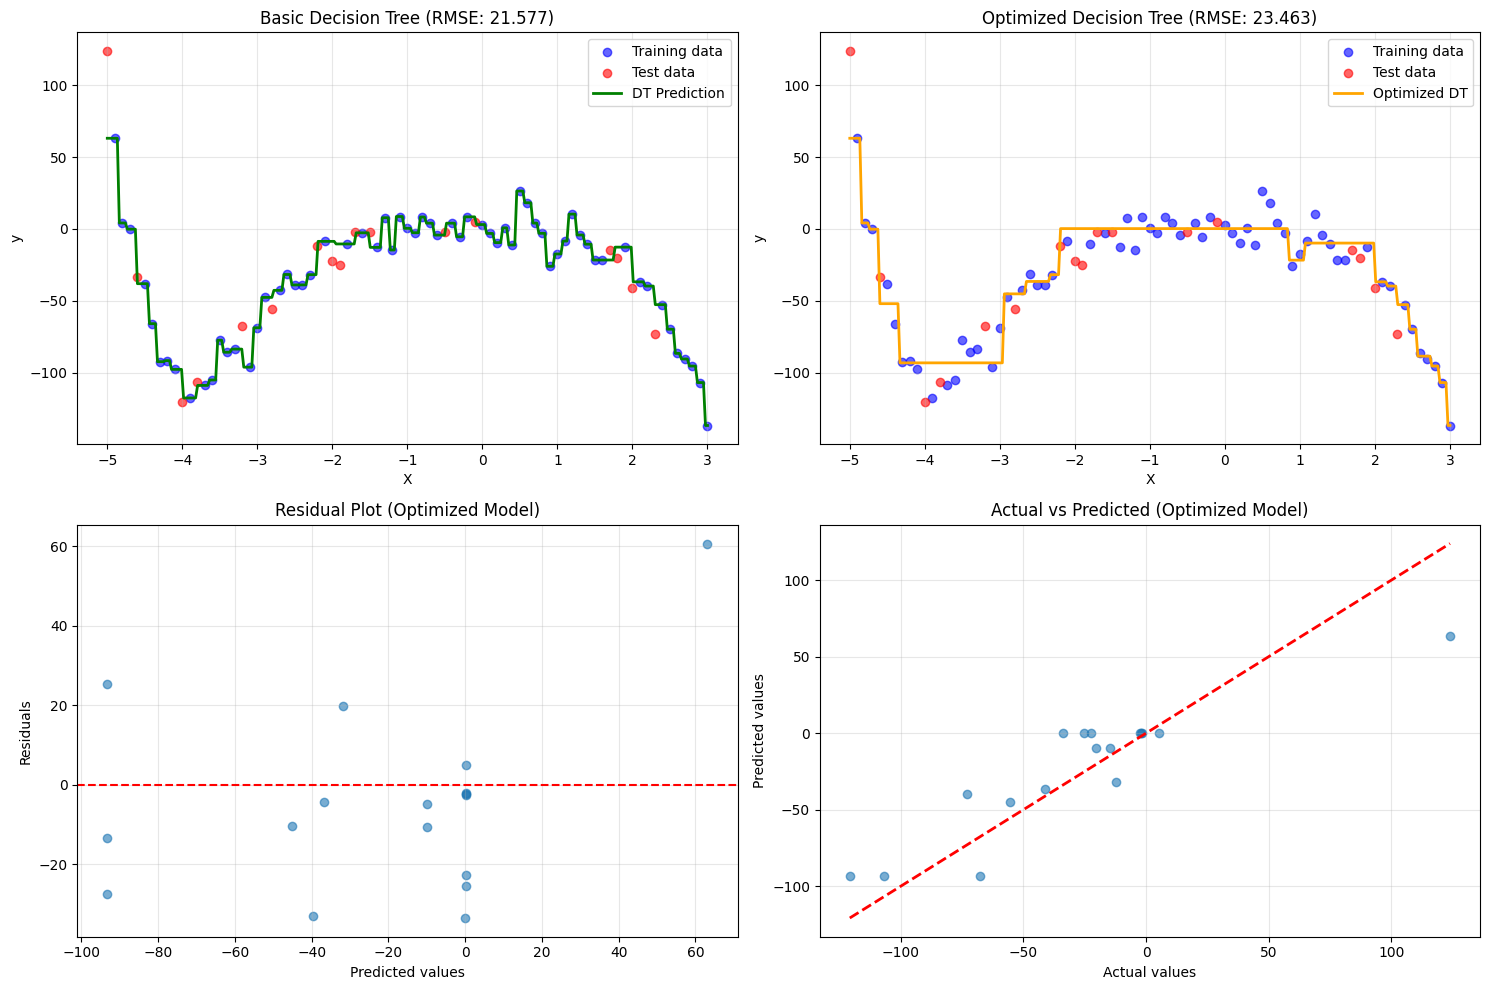

In [7]:
# 预测结果可视化
plt.figure(figsize=(15, 10))

# 创建用于绘制连续预测线的X值
X_plot = np.linspace(X.min().values[0], X.max().values[0], 300).reshape(-1, 1)
y_plot_basic = dt_regressor.predict(X_plot)
y_plot_best = best_dt.predict(X_plot)

# 1. 基础模型结果
plt.subplot(2, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, color="blue", label="Training data")
plt.scatter(X_test, y_test, alpha=0.6, color="red", label="Test data")
plt.plot(X_plot, y_plot_basic, color="green", linewidth=2, label="DT Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Basic Decision Tree (RMSE: {test_rmse:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 优化后模型结果
plt.subplot(2, 2, 2)
plt.scatter(X_train, y_train, alpha=0.6, color="blue", label="Training data")
plt.scatter(X_test, y_test, alpha=0.6, color="red", label="Test data")
plt.plot(X_plot, y_plot_best, color="orange", linewidth=2, label="Optimized DT")
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Optimized Decision Tree (RMSE: {best_test_rmse:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 残差图
plt.subplot(2, 2, 3)
residuals = y_test - y_test_pred_best
plt.scatter(y_test_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Optimized Model)")
plt.grid(True, alpha=0.3)

# 4. 实际值 vs 预测值
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_test_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted (Optimized Model)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

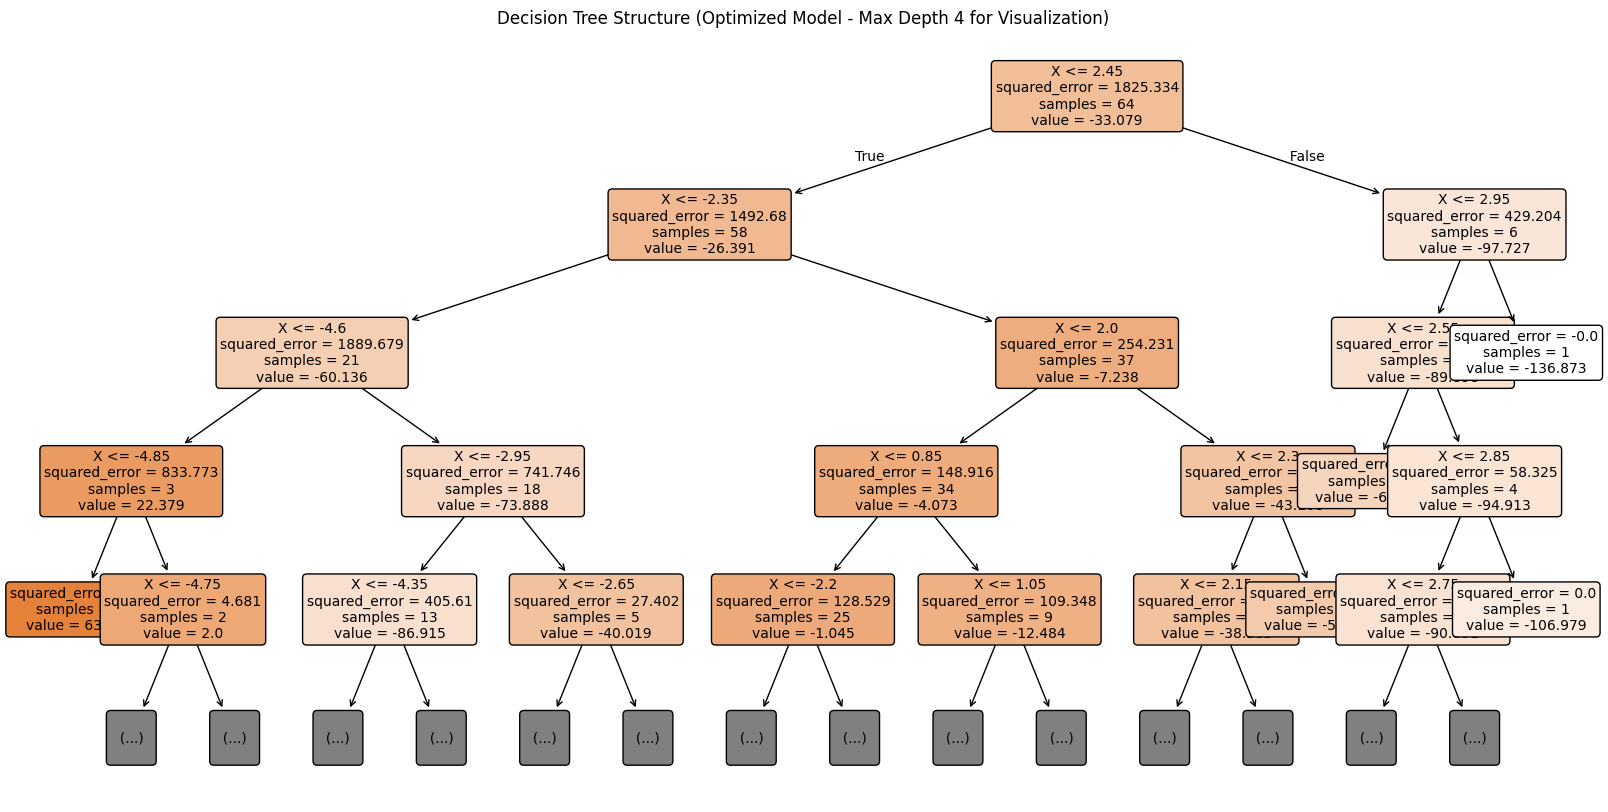

Note: This visualization shows only the first 4 levels of the tree.
The actual optimized tree has depth: 5


In [9]:
# 决策树结构可视化
plt.figure(figsize=(20, 10))

# 可视化优化后的决策树（限制深度以便显示）
plot_tree(
    best_dt, feature_names=["X"], filled=True, rounded=True, fontsize=10, max_depth=4
)  # 限制显示深度
plt.title("Decision Tree Structure (Optimized Model - Max Depth 4 for Visualization)")
plt.show()

print(f"Note: This visualization shows only the first 4 levels of the tree.")
print(f"The actual optimized tree has depth: {best_dt.get_depth()}")

In [8]:
# 交叉验证评估
print("Cross-validation results:")
print("=" * 50)

# 基础模型交叉验证
cv_scores_basic = cross_val_score(
    dt_regressor, X, y, cv=5, scoring="neg_mean_squared_error"
)
cv_rmse_basic = np.sqrt(-cv_scores_basic)

print(f"Basic Decision Tree:")
print(f"  CV RMSE: {cv_rmse_basic.mean():.4f} (+/- {cv_rmse_basic.std() * 2:.4f})")

# 优化模型交叉验证
cv_scores_best = cross_val_score(best_dt, X, y, cv=5, scoring="neg_mean_squared_error")
cv_rmse_best = np.sqrt(-cv_scores_best)

print(f"Optimized Decision Tree:")
print(f"  CV RMSE: {cv_rmse_best.mean():.4f} (+/- {cv_rmse_best.std() * 2:.4f})")

# 性能对比表
print("\nModel Comparison Summary:")
print("=" * 60)
print(f"{'Metric':<20} {'Basic DT':<15} {'Optimized DT':<15}")
print("-" * 60)
print(f"{'Test RMSE':<20} {test_rmse:<15.4f} {best_test_rmse:<15.4f}")
print(f"{'Test R²':<20} {test_r2:<15.4f} {best_test_r2:<15.4f}")
print(f"{'CV RMSE':<20} {cv_rmse_basic.mean():<15.4f} {cv_rmse_best.mean():<15.4f}")
print(f"{'Tree Depth':<20} {dt_regressor.get_depth():<15} {best_dt.get_depth():<15}")
print(
    f"{'Num Leaves':<20} {dt_regressor.get_n_leaves():<15} {best_dt.get_n_leaves():<15}"
)

Cross-validation results:
Basic Decision Tree:
  CV RMSE: 37.0032 (+/- 49.3191)
Optimized Decision Tree:
  CV RMSE: 35.9103 (+/- 48.5205)

Model Comparison Summary:
Metric               Basic DT        Optimized DT   
------------------------------------------------------------
Test RMSE            21.5771         23.4626        
Test R²              0.8282          0.7969         
CV RMSE              37.0032         35.9103        
Tree Depth           15              5              
Num Leaves           64              19             


In [ ]:
# 特征重要性分析
print("Feature Importance Analysis:")
print("=" * 40)

feature_importance = best_dt.feature_importances_
feature_names = ["X"]

print(f"Feature '{feature_names[0]}' importance: {feature_importance[0]:.6f}")

# 由于只有一个特征，我们分析不同深度对性能的影响
depths = range(1, 16)
train_scores = []
test_scores = []

print("\nDepth Analysis:")
print(f"{'Depth':<8} {'Train RMSE':<12} {'Test RMSE':<12} {'Overfitting':<12}")
print("-" * 50)

for depth in depths:
    dt_depth = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_depth.fit(X_train, y_train)

    train_pred = dt_depth.predict(X_train)
    test_pred = dt_depth.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_scores.append(train_rmse)
    test_scores.append(test_rmse)

    overfitting = test_rmse - train_rmse
    print(f"{depth:<8} {train_rmse:<12.4f} {test_rmse:<12.4f} {overfitting:<12.4f}")

# 绘制深度 vs 性能图
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, "b-", label="Training RMSE", marker="o")
plt.plot(depths, test_scores, "r-", label="Test RMSE", marker="s")
plt.xlabel("Tree Depth")
plt.ylabel("RMSE")
plt.title("Decision Tree Performance vs Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 找到最佳深度
best_depth_idx = np.argmin(test_scores)
best_depth = depths[best_depth_idx]
print(
    f"\nBest depth based on test RMSE: {best_depth} (RMSE: {test_scores[best_depth_idx]:.4f})"
)

## 总结与结论

### 模型性能总结
1. **基础决策树**: 未经优化的决策树可能存在过拟合问题
2. **优化决策树**: 通过网格搜索找到了最佳超参数组合，提升了泛化性能
3. **交叉验证**: 确保了模型性能的稳定性和可靠性

### 主要发现
- 决策树能够很好地捕捉数据中的非线性关系
- 适当的剪枝（通过限制深度、最小样本数等）能有效防止过拟合
- 单特征回归问题中，决策树通过分段常数函数进行拟合

### 模型优缺点
**优点**:
- 易于理解和解释
- 不需要数据预处理（标准化等）
- 能够处理非线性关系
- 对异常值相对鲁棒

**缺点**:
- 容易过拟合
- 对训练数据的小变化敏感
- 单一决策树的预测能力有限